In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rfm = pd.read_csv('../data/processed/rfm_clustered.csv', index_col='Customer ID')
print(rfm.shape)
rfm.head()


(5881, 5)


,Recency,Frequency,Monetary,KMeans_Cluster,Persona
Customer ID,,,,,
12346.0,326,12,77556.46,3,At-Risk
12347.0,2,8,4921.53,1,Champions
12348.0,75,5,2019.40,3,At-Risk
12349.0,19,4,4428.69,1,Champions
12350.0,310,1,334.40,2,Lost


In [2]:
persona_stats = rfm.groupby('Persona').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Median_Monetary=('Monetary', 'median'),
    Customer_Count=('Recency', 'count'),
    Total_Revenue=('Monetary', 'sum')
).round(1)

persona_stats['Pct_Customers'] = (persona_stats['Customer_Count'] / len(rfm) * 100).round(1)
persona_stats['Pct_Revenue'] = (persona_stats['Total_Revenue'] / rfm['Monetary'].sum() * 100).round(1)

print(persona_stats)


               Avg_Recency  Avg_Frequency  Avg_Monetary  Median_Monetary  \
Persona                                                                    
At-Risk              245.0            4.7        1855.9           1341.8   
Champions             30.1           17.9        9688.4           4464.9   
Lost                 400.3            1.3         301.8            257.1   
New/Promising         30.3            2.8         774.8            680.8   

               Customer_Count  Total_Revenue  Pct_Customers  Pct_Revenue  
Persona                                                                   
At-Risk                  1443      2678007.4           24.5         15.4  
Champions                1363     13205353.3           23.2         76.0  
Lost                     1884       568599.7           32.0          3.3  
New/Promising            1191       922843.9           20.3          5.3  


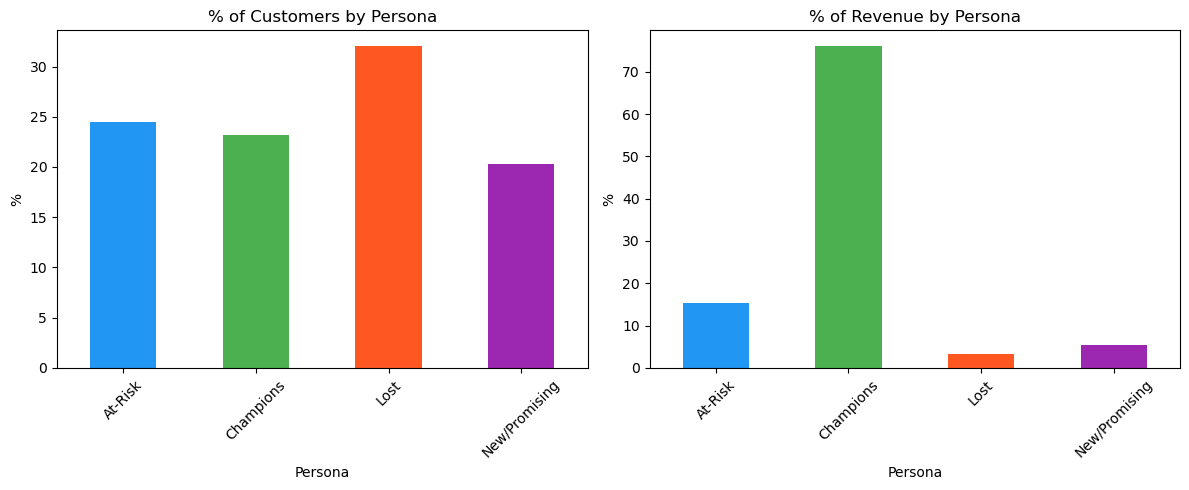

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

persona_stats['Pct_Customers'].plot(kind='bar', ax=axes[0], color=['#2196F3','#4CAF50','#FF5722','#9C27B0'])
axes[0].set_title('% of Customers by Persona')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=45)

persona_stats['Pct_Revenue'].plot(kind='bar', ax=axes[1], color=['#2196F3','#4CAF50','#FF5722','#9C27B0'])
axes[1].set_title('% of Revenue by Persona')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




The graphic shows clear results:

**Champions (23.2% of customers, 76% of revenue)**

Retain: Enroll in a VIP/loyalty program. Offer early access to new products.
Grow: Cross-sell complementary categories based on purchase history.
Monitor: Set automated alerts if a Champion's recency exceeds 60 days — trigger a personalized re-engagement email immediately.

**New/Promising (20.3% of customers, 5.3% of revenue)**

Action: Send a "thank you for your first purchase" email with a discount on the second order.
Educate: Showcase bestsellers and popular categories to broaden their basket(since have potential to grow).
Goal: Convert even 20% of this segment into repeat buyers, and that would significantly increase total revenue. 

**At-Risk (24.5% of customers, 15.4% of revenue)**

Win-back: Send a campaign with a time-limited discount.
Urgency: They were once valuable (avg £1,856) — every month of inaction increases churn probability.
Financial impact: Recovering 20% of At-Risk customers = ~£535,600 in recovered revenue (20% × £2,678,007).

**Lost (32.0% of customers, 3.3% of revenue)**

Low priority: Don't invest heavily, since the ROI is low.
Test: Run one low-cost reactivation email. If no response, suppress from future campaigns save further potential cost.
Actions: Some churn is natural. Redirect saved budget toward Champions and At-Risk.

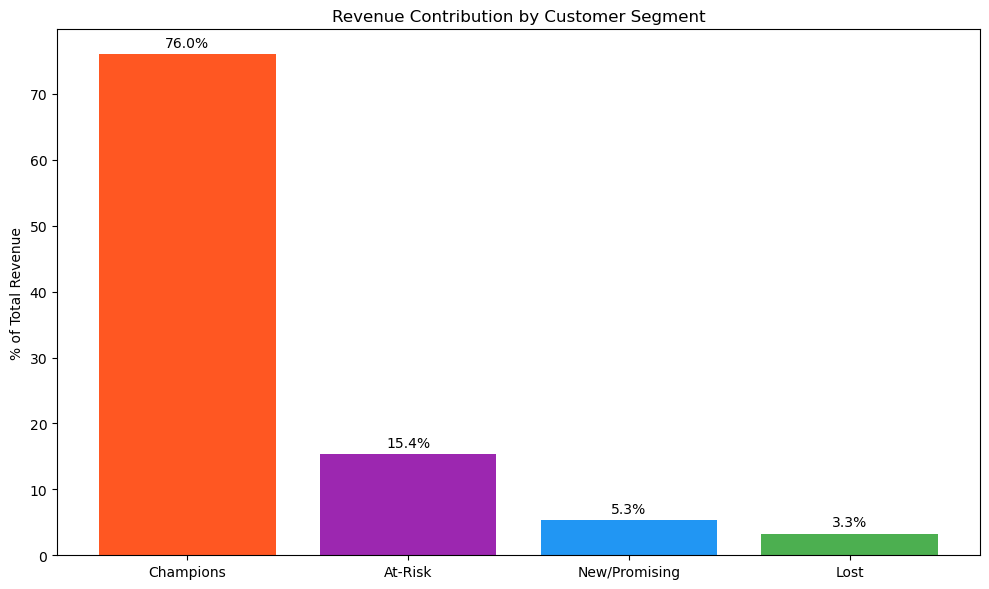

In [4]:
persona_order = ['Champions', 'At-Risk', 'New/Promising', 'Lost']
colors = ['#FF5722', '#9C27B0', '#2196F3', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(persona_order,
              [persona_stats.loc[p, 'Pct_Revenue'] for p in persona_order],
              color=colors)

ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('% of Total Revenue')
ax.set_title('Revenue Contribution by Customer Segment')
plt.tight_layout()
plt.show()
